In [2]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np

/var/folders/fb/xl0hnskx527bfqkv38l3sn7h0000gn/T/ipykernel_13719/3596107838.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
import seaborn as sns

In [4]:
data=pd.read_csv(r'/Users/jiricerny/_Git/_venv/_venv/Pyth3_2024/_data/FlightsData/flights.csv',low_memory=False)

In [5]:
miles=data.groupby('MONTH')[['DISTANCE']].sum()
miles.head()

,DISTANCE
MONTH,
1,377507097
2,343689908
3,411546494
4,396371301
5,409185797


In [6]:
miles['km']=miles.DISTANCE*1.6
miles.head()

,DISTANCE,km
MONTH,,
1,377507097,604011355.2
2,343689908,549903852.8
3,411546494,658474390.4
4,396371301,634194081.6
5,409185797,654697275.2


In [7]:
import numpy as np
import calendar as cal

In [8]:
cal.month_name[1:13]

['January',
 'February',
 'March',
 'April',
 'May',
 'June',
 'July',
 'August',
 'September',
 'October',
 'November',
 'December']

In [9]:
miles.index=np.vectorize(lambda x:cal.month_name[x])(miles.index)
miles.head()

,DISTANCE,km
January,377507097,604011355.2
February,343689908,549903852.8
March,411546494,658474390.4
April,396371301,634194081.6
May,409185797,654697275.2


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

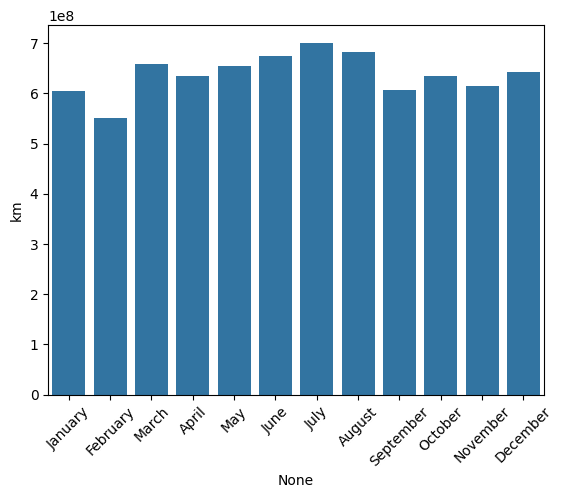

In [11]:
sns.barplot(x=miles.index, y=miles.km, data=miles)
plt.xticks(rotation=45)
plt.show()

In [12]:
numFlights=data.groupby(['MONTH','DAY_OF_WEEK'])[['FLIGHT_NUMBER']].count()
numFlights

FLIGHT_NUMBER
MONTH DAY_OF_WEEK               
1     1                    64167
      2                    60837
      3                    62141
      4                    78022
      5                    80955
...                          ...
12    3                    80550
      4                    75587
      5                    61821
      6                    54436
      7                    62591

[84 rows x 1 columns]

In [13]:
#graf dodelat

<Axes: xlabel='MONTH,DAY_OF_WEEK'>

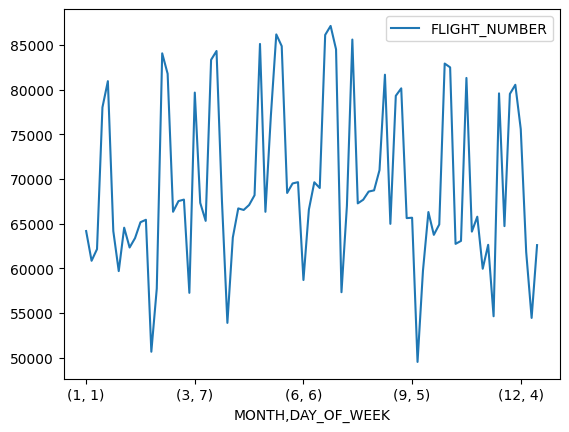

In [14]:
numFlights.plot()

In [15]:
canc=data.groupby(['MONTH','DAY_OF_WEEK','CANCELLED'])[['CANCELLED']].count()

In [16]:
canc.rename(columns={'CANCELLED':'COUNT'},inplace=True)

In [17]:
canc

COUNT
MONTH DAY_OF_WEEK CANCELLED       
1     1           0          61628
                  1           2539
      2           0          57269
                  1           3568
      3           0          60799
...                            ...
12    5           1            368
      6           0          53771
                  1            665
      7           0          61147
                  1           1444

[168 rows x 1 columns]

In [18]:
canc.reset_index(inplace=True)

In [19]:
canc

,MONTH,DAY_OF_WEEK,CANCELLED,COUNT
0,1,1,0,61628
1,1,1,1,2539
2,1,2,0,57269
3,1,2,1,3568
4,1,3,0,60799
...,...,...,...,...
163,12,5,1,368
164,12,6,0,53771
165,12,6,1,665
166,12,7,0,61147


In [20]:
canc.MONTH=np.vectorize(lambda x: cal.month_name[x])(canc.MONTH)

In [21]:
canc.DAY_OF_WEEK=np.vectorize(lambda x: cal.day_name[x-1])(canc.DAY_OF_WEEK)

In [22]:
canc.CANCELLED=np.vectorize(lambda x: 'yes' if x==1 else 'no')(canc.CANCELLED)

In [23]:
canc

,MONTH,DAY_OF_WEEK,CANCELLED,COUNT
0,January,Monday,no,61628
1,January,Monday,yes,2539
2,January,Tuesday,no,57269
3,January,Tuesday,yes,3568
4,January,Wednesday,no,60799
...,...,...,...,...
163,December,Friday,yes,368
164,December,Saturday,no,53771
165,December,Saturday,yes,665
166,December,Sunday,no,61147


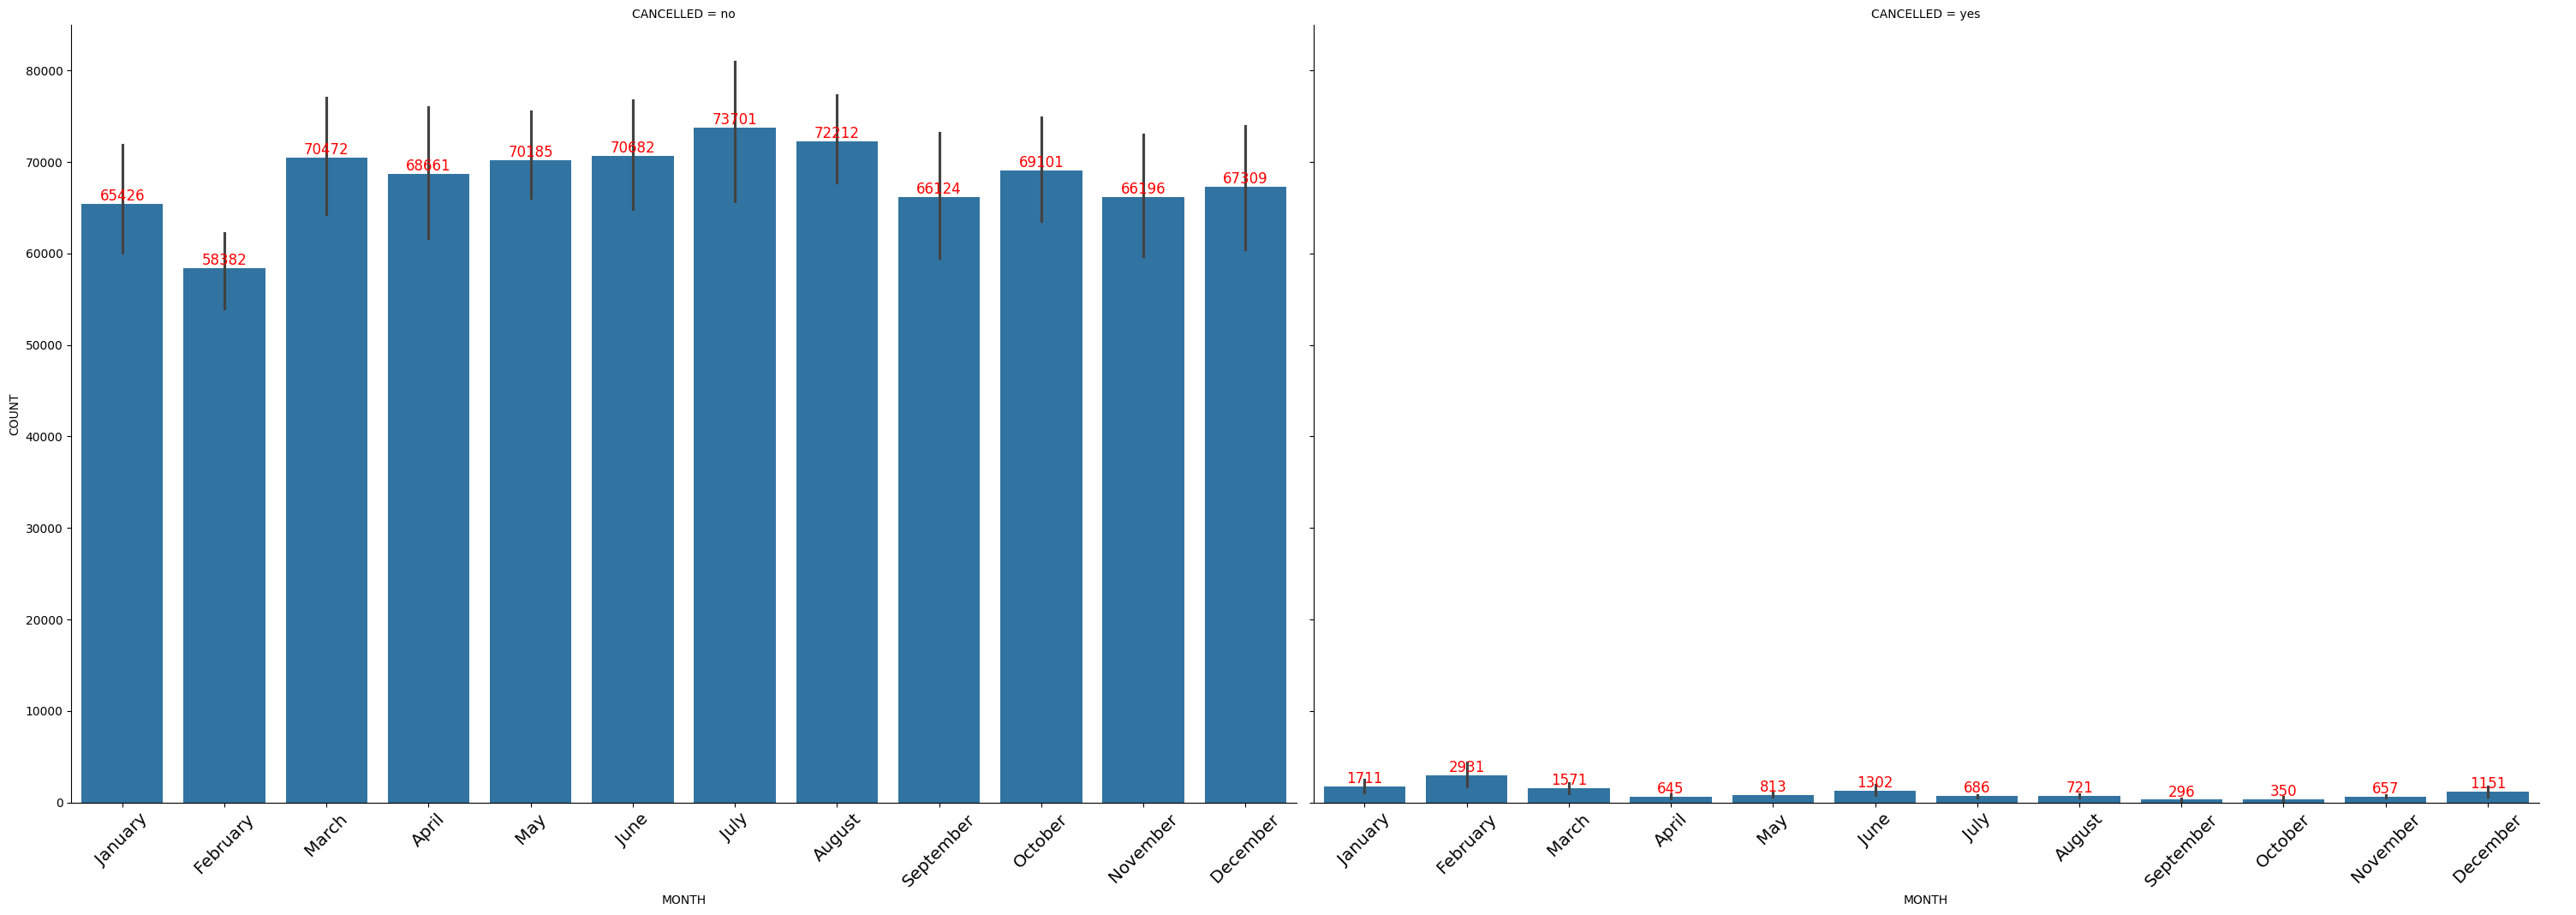

In [24]:
gr=sns.catplot(x='MONTH', y='COUNT', data=canc, col = 'CANCELLED', kind='bar', aspect=1.5, height = 10)
gr.set_xticklabels(fontsize='x-large', rotation=45)

ax = gr.axes[0][0]

for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2, p.get_height(), "%d" % int(p.get_height()),fontsize=12, color='red', ha='center', va='bottom')
    
ax = gr.axes[0][1]

for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2, p.get_height(), "%d" % int(p.get_height()),fontsize=12, color='red', ha='center', va='bottom')

In [25]:
pivoted=canc.pivot_table(index='DAY_OF_WEEK', columns='MONTH', values='COUNT')

In [26]:
pivoted

MONTH,April,August,December,February,January,July,June,March,May,November,October,September
DAY_OF_WEEK,,,,,,,,,,,,
Friday,33758.5,34362.5,30910.5,32714.5,40477.5,42261.5,34821.0,33844.5,42562.5,31312.0,41250.5,32829.0
Monday,33662.0,42807.5,32358.5,32271.5,32083.5,34815.0,43096.0,42035.0,33351.5,40657.5,33147.5,32486.0
Saturday,26939.5,35494.5,27218.0,25324.5,32082.5,28658.0,29341.5,28622.5,33161.0,27311.0,31365.5,24754.0
Sunday,31722.0,40839.5,31295.5,28858.5,29840.5,33492.5,33285.0,39837.5,38523.5,39793.5,31531.5,29862.5
Thursday,42166.5,34293.5,37793.5,32578.0,39011.0,43571.0,34749.0,33762.5,34090.0,29973.5,41463.5,32808.5
Tuesday,32654.5,33633.0,39764.0,31161.5,30418.5,34493.5,42439.5,40891.5,33264.5,32051.0,31871.0,39657.5
Wednesday,41672.5,33837.5,40275.0,31687.0,31070.5,43067.5,34216.5,33162.5,33543.5,32887.5,32453.0,40075.5


<Axes: xlabel='DAY_OF_WEEK'>

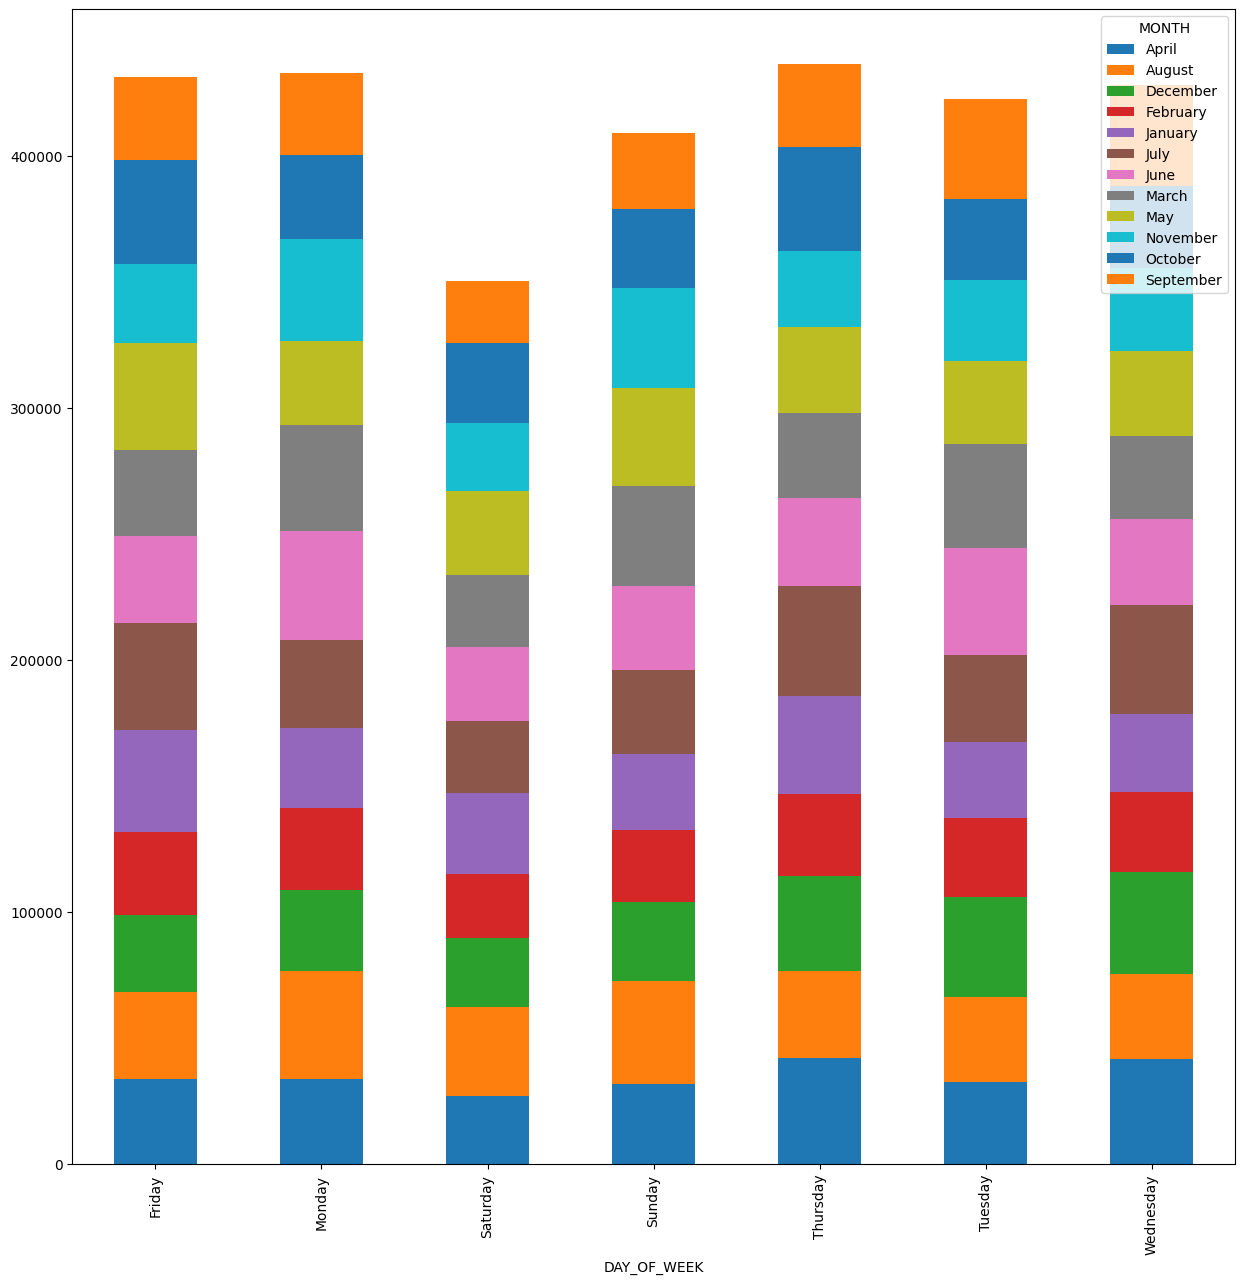

In [27]:
#dodelat popisky
f,a=plt.subplots(1,1,figsize=(15,15))
pivoted.plot(ax=a, kind='bar', stacked=True)